# US Home Prices, Inventory, and Mortgage Index (2016 – Present)

## US Housing Market Dynamics: Actual Figures, Inventory Growth, & Mortgage Rates

### Description

This notebook provides a technical visualization of U.S. macro housing trends. It utilizes data from the Federal Reserve Economic Data (FRED) to analyze and cross-reference:

- **30-Year Fixed Rate Mortgage (`MORTGAGE30US`):** Weekly average fixed mortgage rates and their year-over-year rate changes.
- **Active Listing Count (`ACTLISCOUUS`):** Monthly total housing inventory levels coupled with a 3-month moving average of month-over-month growth.
- **Median Sales Price of Houses Sold (`MSPUS`):** Quarterly median home sales pricing contrasted against corresponding macro interest rates.

The analysis tracks both actual index figures and underlying changes to highlight shifts in structural supply, affordability, and macro-driven real estate trends.

---

## Objectives

- Analyze housing supply elasticity and inventory trends from 2016 to the present day.
- Compare home price trajectories with the direct velocity of mortgage rate changes.
- Identify inflection points where interest rate spikes explicitly cool down or bottleneck active listings.
- Provide a time-logged macroeconomic analysis of the US housing landscape.

---

## Data Sources

- Federal Reserve Economic Data (FRED)
  - `MORTGAGE30US`: 30-Year Fixed Rate Mortgage Average in the United States (Weekly)
  - `ACTLISCOUUS`: Housing Inventory: Active Listing Count in the United States (Monthly)
  - `MSPUS`: Median Sales Price of Houses Sold for the United States (Quarterly)

## Pre-Processing

### Install System Dependencies

In [10]:
!pip install pandas-datareader
# Note: Uncomment below if necessary to ugrade installer
# !pip3 install --upgrade pip

### Import Python Libraries

In [11]:
import pandas as pd
import numpy as np
import datetime as dt
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import pandas_datareader.data as web
from datetime import datetime, timedelta
from dateutil.relativedelta import relativedelta

### Standard Unit Initial Timeframe

In [12]:
start = datetime(2016, 1, 1)
end = datetime.now()
str_current_date = end.strftime("%B %d, %Y")
plot_start = start + relativedelta(years=1)

## U.S. 30-yr Fixed Rate Mortgage Net Changes (2016 - Present)

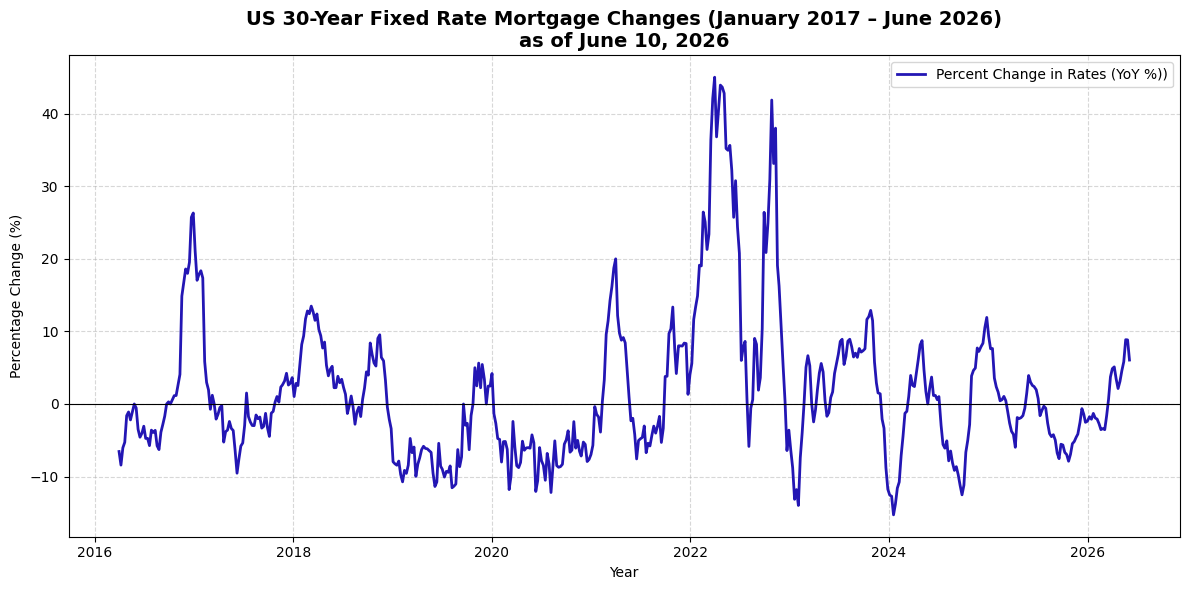

In [13]:
# Source : FRED
df_fixed = web.DataReader('MORTGAGE30US', 'fred', start, end)
df_yoy = df_fixed.pct_change(periods = 12) * 100

# Plotting
plt.figure(figsize = (12, 6))
plt.plot(df_yoy.index, df_yoy['MORTGAGE30US'], label = 'Percent Change in Rates (YoY %))', color = "#2316b4", linewidth =2)

plt.title(f'US 30-Year Fixed Rate Mortgage Changes ({plot_start.strftime("%B %Y")} – {end.strftime("%B %Y")})\nas of {str_current_date}', fontsize = 14, fontweight = 'bold')
plt.xlabel('Year')
plt.ylabel('Percentage Change (%)')
plt.axhline(0, 
            color = 'black', 
            linewidth = 0.8, 
            linestyle = '-')
plt.grid(True, 
         which = 'both', 
         linestyle = '--', 
         alpha = 0.5)
plt.legend()
plt.tight_layout()

plt.show()

## US Housing Inventory and Net Change (2016 - Present)

<Figure size 1600x600 with 0 Axes>

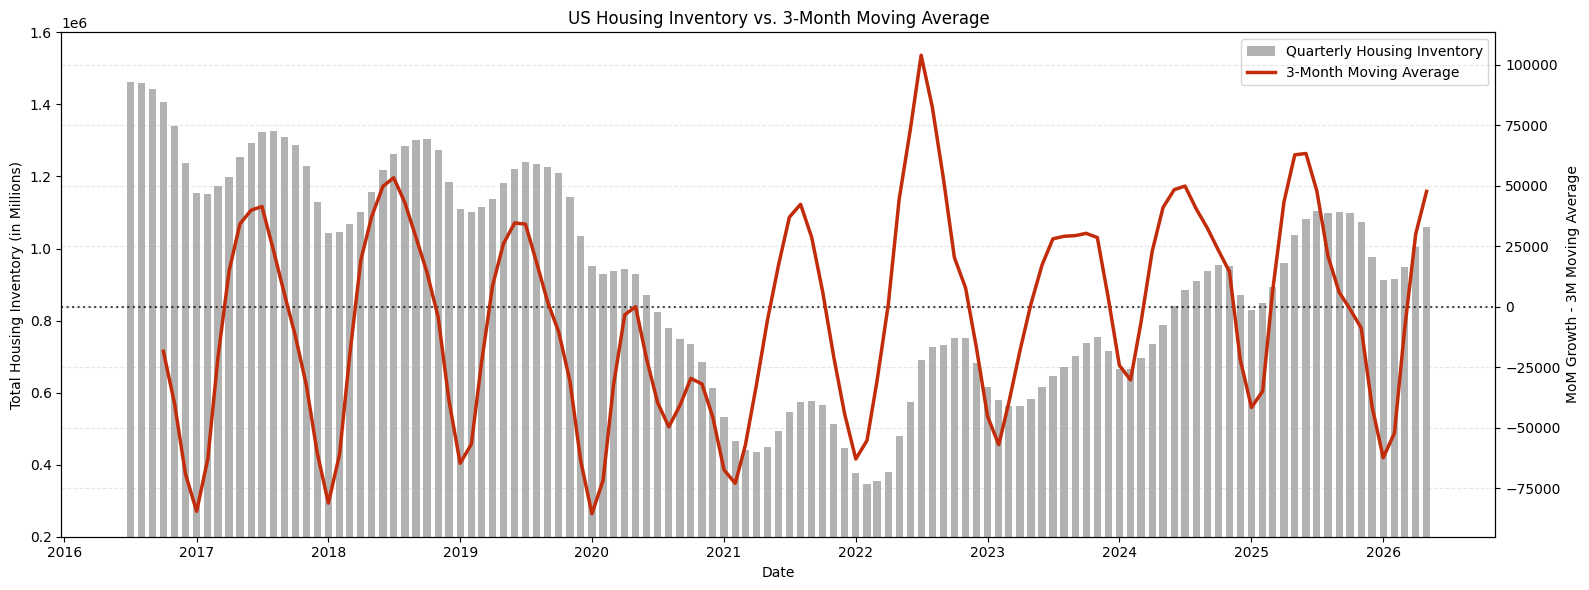

In [14]:
# Source : FRED
df = web.DataReader("ACTLISCOUUS", "fred", start, end)

df["housing_growth"] = df["ACTLISCOUUS"].diff()
df["ma_3"] = df["housing_growth"].rolling(3).mean()

df_focus = df[(df.index >= start)]

plt.figure(figsize = (16, 6)) 

fig, ax1 = plt.subplots(figsize = (16, 6))

# inventory bar graph
ax1.set_xlabel("Date")
ax1.set_ylabel("Total Housing Inventory (in Millions)", color = "black")
ax1.tick_params(axis = "y", labelcolor = "black")
ax1.set_ylim(200000, 1600000)
ax1.bar(
    df_focus.index,
    df_focus["ACTLISCOUUS"],
    color = "grey",
    width = 20,
    alpha = 0.6,
    label = "Quarterly Housing Inventory",
)

# copy left axis
ax2 = ax1.twinx()

# inventory moving average
ax2.set_ylabel("MoM Growth - 3M Moving Average", color = "black")
ax2.tick_params(axis = "y", labelcolor = "black")
ax2.axhline(0, color = "black", 
            linestyle = ":", 
            linewidth = 1.5, 
            alpha = 0.7)
ax2.plot(
    df_focus.index,
    df_focus["ma_3"],
    color = "#c22c0a",
    linewidth = 2.5,
    label = "3-Month Moving Average",
)

ax1.xaxis.set_major_locator(mdates.YearLocator())
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

plt.title(
    "US Housing Inventory vs. 3-Month Moving Average"
)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc = "upper right")

plt.grid(axis = "y", linestyle = "--", alpha = 0.3)
fig.tight_layout()

plt.show()


### 30 year Mortgage Rates vs. Median Home Prices (2016 - Present)

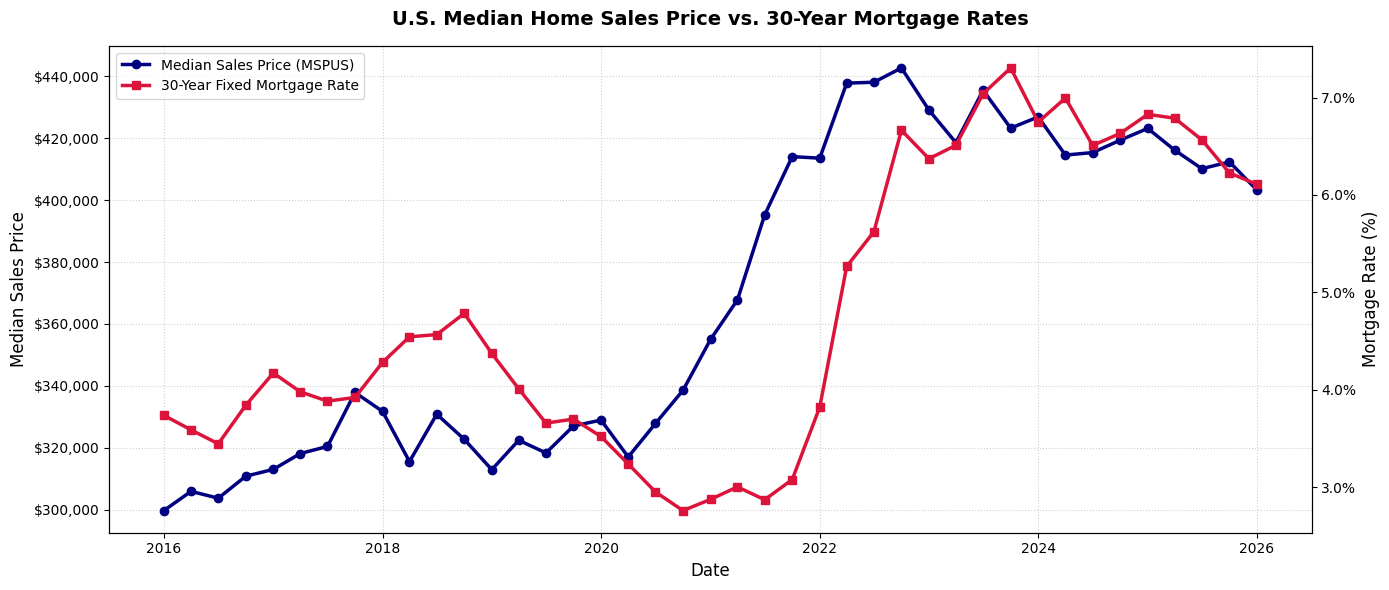

In [15]:
# Source : FRED
df_median = web.DataReader("MSPUS", "fred", start, end)  # Quarterly
df_mortgage = web.DataReader("MORTGAGE30US", "fred", start, end)  # Weekly

# pre-processing
df_quarterly = pd.DataFrame(index = df_median.index)
df_quarterly["Median_Sales_Price"] = df_median["MSPUS"]
df_quarterly["Avg_Mortgage_Rate"] = df_mortgage.resample("QS").mean()

df_quarterly.dropna(inplace = True)

# plotting: axis I
fig, ax1 = plt.subplots(figsize = (14, 6))

ax1.plot(
    df_quarterly.index,
    df_quarterly["Median_Sales_Price"],
    color = "navy",
    linewidth = 2.5,
    marker = "o",
    label = "Median Sales Price (MSPUS)",
)
ax1.set_xlabel("Date", fontsize = 12)
ax1.set_ylabel("Median Sales Price", color = "black", fontsize = 12)
ax1.tick_params(axis = "y", labelcolor = "black")
ax1.yaxis.set_major_formatter("${x:,.0f}")  # Formats as $400,000

# plotting: axis II
ax2 = ax1.twinx()
ax2.plot(
    df_quarterly.index,
    df_quarterly["Avg_Mortgage_Rate"],
    color = "crimson",
    linewidth = 2.5,
    marker = "s",
    label = "30-Year Fixed Mortgage Rate",
)
ax2.set_ylabel("Mortgage Rate (%)", color = "black", fontsize = 12)
ax2.tick_params(axis = "y", labelcolor = "black")
ax2.yaxis.set_major_formatter("{x:.1f}%")  # Formats as 6.5%

# formatting: plot
plt.title(
    "U.S. Median Home Sales Price vs. 30-Year Mortgage Rates",
    fontsize = 14,
    fontweight = "bold",
    pad = 15,
)

# formatting: axis
ax1.xaxis.set_major_locator(mdates.YearLocator(2))
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

# merging
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc = "upper left")

ax1.grid(True, linestyle = ":", alpha = 0.6)
fig.tight_layout()

plt.show()

# Conclusions and Observations

***In progress***

## Update Schedule
### TBA

#### ***Review and analysis publishing on Friday, -----, 2026, at 1:30 P.M. Pacific Time.***